#  Project to recognise handwritten Characters using CNN

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import csv
import pandas as pd
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from sklearn.model_selection import train_test_split

In [2]:
!which jupyter-notebook

/Users/ratanprakash/miniconda3/envs/tf-env/bin/jupyter-notebook


# Load Dataset

In [3]:
img_size = 75
def load_images(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            Rimg = cv2.resize(img, (img_size, img_size))
            images.append([Rimg,filename])
    return images

In [4]:
labels = pd.read_csv('english.csv', index_col = None)

i = 0
while i < 3410:
    labels["Image"][i] = labels["Image"][i][4:]
    i += 1
    

label_dict = labels.set_index("Image").T.to_dict()  ##contains {'image name': 'label'} as key:value pair

/var/folders/23/xnk_h1gj4t374j4cnh56sxwc0000gn/T/ipykernel_85574/4120325776.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  labels["Image"][i] = labels["Image"][i][4:]


In [5]:
input_imgs = load_images("Img")      ##images are loaded as numpy array using this function call 

In [6]:
data = []
for img  in input_imgs:
    data.append([img[0], label_dict[img[1]]["label"]])
    ##keeping   [IMAGE ARRAY, IMAGE LABEL] as list in data 

### Forming a class dict to label all classes to a integer

In [7]:
class_dict = {}
inID = 10
for integer in range(0,10):
    class_dict[str(integer)] = integer

for char in range(65,65+26):
    class_dict[chr(char)] = inID
    inID += 1

for char in range(97,97+26):
    class_dict[chr(char)] = inID
    inID += 1
    
# class_dict  


In [8]:
X_train = []
Y_train = []

for img_array, img_label in data:
    X_train.append(img_array)
    Y_train.append(img_label)
    
X_train = np.array(X_train)  ##contains all the images as img_sizeximg_size array       ##.reshape(-1, img_size, img_size, 1)
Y_train = np.array(Y_train)  ##contains array of all the labels -- 'a' 'b' '0' 

In [9]:
print("Shape of X_train : ", X_train.shape)
print("Shape of Y_train: ", Y_train.shape)

Shape of X_train :  (3410, 75, 75)
Shape of Y_train:  (3410,)


In [10]:
X_train = X_train/255.0   ##scaling the values from 0 to 1

In [11]:
## this block of code CONVERTS the STRING LABELS to INT CLASSES
l = 0
k = []
while l < 3410:
    k.append(class_dict[Y_train[l]])
    l += 1 
Y_train = np.array(k)  ##now Y_train contains labels as ({class dict - labels} INTEGER CLASSES)

In [12]:
X_train = X_train.reshape(len(X_train), img_size, img_size, 1)
Y_train = Y_train.reshape(len(Y_train), 1)

print("Shape of X_train: ", X_train.shape)
print("Shape of Y_train: ", Y_train.shape)

Shape of X_train:  (3410, 75, 75, 1)
Shape of Y_train:  (3410, 1)


In [13]:
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, 
    test_size=0.25, random_state= 8) # 0.25 x 0.8 = 0.2

print("Shape of X_val: ", X_val.shape)
print("Shape of Y_val: ", Y_val.shape)

Shape of X_val:  (853, 75, 75, 1)
Shape of Y_val:  (853, 1)


# tensorflow Model 

In [14]:
model = Sequential([
    Conv2D(128, (3,3), activation = 'relu', input_shape = (img_size, img_size, 1)),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation = 'relu'),
    MaxPooling2D((2,2)),
    
#     Conv2D(16, (3,3), activation = 'relu'),
#     MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(62, activation = 'softmax')
])

/Users/ratanprakash/miniconda3/envs/tf-env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(0.01),
              metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 73, 73, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 36, 36, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 34, 34, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,183,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,196,670 (4.56 MB)

 Trainable params: 1,196,670 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
hist = model.fit(X_train, Y_train, epochs = 100, batch_size = 64)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.0115 - loss: 6.1625
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.0205 - loss: 4.1278
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.0176 - loss: 4.1262
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.0128 - loss: 4.1267
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.0221 - loss: 4.1242
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.0150 - loss: 4.1256
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.0184 - loss: 4.1259
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.0084 - loss: 4.1284
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.0129 - loss: 4.1255
Epoch 10/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.0184 - loss: 4.1246


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0106 - loss: 4.1418


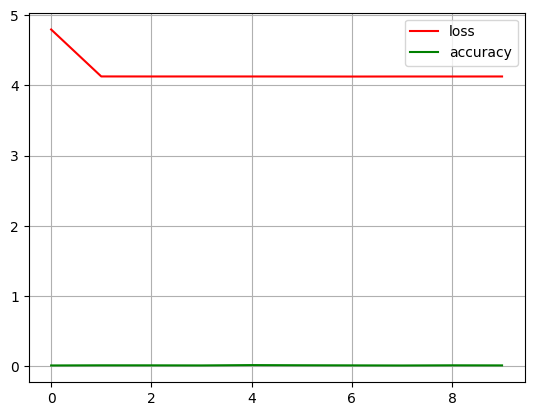

In [17]:
accuracy, loss = model.evaluate(X_val, Y_val)

plt.plot(hist.history['loss'], color = 'red', label = 'loss')
plt.plot(hist.history['accuracy'], color = 'green', label = 'accuracy')
plt.legend(loc = 'upper right')
plt.grid(True)

# plt.plot(accuracy)
# plt.plot(loss)

# Making predictions

Image no. =  2875
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Our model says it is : 7
It is found to be :  7


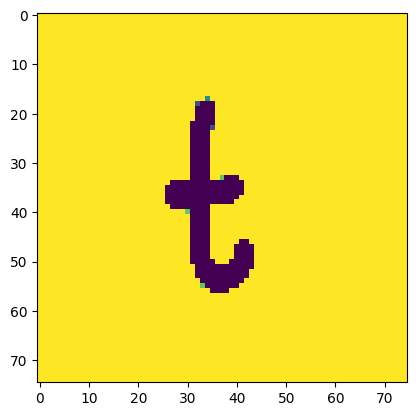

In [18]:
# idx2 = random.randint(0, len(data))
# plt.imshow(data[idx2, 0, :])
# plt.show()
idx = random.randint(0, len(data))
print("Image no. = ",idx)
plt.imshow(data[idx][0]) #cmap = 'gray')
# print("Image label accd to dict: ", y[idx])

y_pred = model.predict(data[idx][0].reshape(1, img_size, img_size, 1))
prediction = np.argmax(y_pred)

print("Our model says it is :", prediction)

print("It is found to be : ", list(class_dict.keys())
      [list(class_dict.values()).index(prediction)])
    
# print(y_pred)

In [19]:
testing_data = os.listdir('test_folder')
r = random.randint(0, len(testing_data)-1)
image = testing_data[r]
path = f"/Users/ratanprakash/Desktop/AIMS projects/AlphaNumeric_classification/test_folder/{image}"
# path = r"/Users/ratanprakash/Documents/tf_project/test_folder/rr.png"

test_image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
test_image = cv2.resize(test_image, (img_size, img_size))
# test_image = np.invert(test_image)
test_image = test_image/255.0
contrast_test_image = np.round_(test_image)
test_image = contrast_test_image
plt.imshow(test_image) #cmap='gray')

test_image = test_image.reshape(1, img_size, img_size, 1)
y_pred = model.predict(test_image)
prediction = np.argmax(y_pred)

print("Our model says it is a :", prediction)
print("It is estimated to be : ", list(class_dict.keys())
      [list(class_dict.values()).index(prediction)])
print(image)

[ WARN:0@157.717] global loadsave.cpp:241 findDecoder imread_('/Users/ratanprakash/Documents/tf_project/test_folder/Screenshot 2022-10-28 at 2.39.37 AM.png'): can't open/read file: check file path/integrity


error: OpenCV(4.10.0) /Users/xperience/GHA-Actions-OpenCV/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/resize.cpp:4152: error: (-215:Assertion failed) !ssize.empty() in function 'resize'
